<div style="display: flex; flex-direction: row; align-items: center;">
    <div style="flex : 0; margin-top:45px;">
        <img src="https://img.grepmed.com/uploads/5117/bony-handxray-progression-handbones-clinical-original.gif" alt="Image" style="max-width: 400px; height:500px;" />
    </div>
    <div style="flex: 1; margin-left: 30px; margin-top: 6px">
<h3><b><font style="color: crimson; margin-bottom: 20px;font-size: 140%;font-family:Impact;">Osteoporosis Risk Prediction from X-ray Images</font></b></h3>
Osteoporosis is a skeletal disease where bones become weak and brittle, increasing fracture risk. This notebook builds a <b>multi-input deep learning pipeline</b> that fuses hand X-ray images with tabular metadata (bone age + gender) to predict osteoporosis risk class.<br><br>
<h3><b><font style="color: crimson; margin-bottom: 20px;font-size: 140%;font-family:Impact;">Why Multi-Input?</font></b></h3>
X-ray images carry visual bone density and structural information. Combined with clinical metadata (bone age, gender), a fused model is significantly more accurate than using either source alone.<br><br>
<b style="color:navy">Risk Classes:</b><br>
<font style="color: navy; font-weight:bold">→ Class 0: Low Risk</font><br>
<font style="color: navy; font-weight:bold">→ Class 1: Medium Risk</font><br>
<font style="color: navy; font-weight:bold">→ Class 2: High Risk</font><br>
    </div>
</div>

In [ ]:
from IPython.core.display import HTML

css_styling= """<style>
img.center { display: block; margin: 0 auto; }
@import url('https://fonts.googleapis.com/css2?family=Poppins:wght@400;500;600&display=swap');
@import url('https://fonts.googleapis.com/css2?family=Bebas+Neue&display=swap');
:root{ --poppins-font: 'Poppins', sans-serif; --bebas-font: 'Bebas Neue', cursive; }
body{ font-family: var(--poppins-font); }
.ref-btn{ padding:1.60rem 0.75rem; border: 2px solid; border-radius: 0.5rem; color: white; margin-top: auto; }
.ref-btn:hover{ color: black; transition: background-color 0.7s ease; }
#container { width:880px; font-family:verdana,arial,helvetica,sans-serif; font-size:11px; text-align:center; margin:auto; }
#container a { display:block; color:white; text-decoration:none; background-color:dimgray; transition: all 0.5s; }
#container a:hover { color:white; background-color:Crimson; }
#no1 { width:190px; line-height:60px; border:1px solid #000; margin-left:370px; }
#no1 a { height:60px; }
#line1 { font-size:0; width:1px; height:20px; color:#fff; background-color:#000; margin-left:466px; }
#line2 { font-size:0; width:600px; height:1px; color:#fff; background-color:#000; margin:auto; }
.clear { clear:both; }
</style>"""
HTML(css_styling)

<br><br><br>

# <p><center style="background-white:aqua;font-family:Gabriola;color:navy;font-size:170%;text-align:center;border-radius:10px 70px;">  Osteoporosis Risk Prediction: Xception + Tabular Fusion Model </center></p>

<p><center style="color:blue; font-family:cursive;font-size:120%;">________  Data Loading, EDA, Multi-Input Modeling, Evaluation, Grad-CAM  ________ </center></p>

<a id="Table"></a>
<div id="container">
  <div id="no1"><a href="#Table">Table of Contents</a></div>
  <div id="line1"></div>
  <div id="line2"></div>
</div>

## Sections
1. [Imports & Setup](#libraries)
2. [Load & Merge Datasets](#dataset)
3. [Exploratory Data Analysis](#eda)
4. [Data Preprocessing & Split](#preprocessing)
5. [Multi-Input Model Architecture](#model)
6. [Training Pipeline](#training)
7. [Evaluation](#evaluation)
8. [Risk Score Mapping](#risk)
9. [Grad-CAM Explainability](#gradcam)

<a id="libraries"></a>
# <b> <span style='color:dimgray'>Chapter 1 </span> <span style='color:blue'>|</span><span style='color:red'> Imports & Setup</span> </b>

<p style="color:crimson">All required libraries for deep learning, image processing, and explainability.</p>

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import os
import cv2
import random
import numpy as np
import pandas as pd
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.image import imread
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, auc)
from itertools import cycle

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Model, layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Input, Dense, Dropout, Flatten,
                                      GlobalAveragePooling2D, Concatenate,
                                      BatchNormalization)
from tensorflow.keras.applications import Xception
from tensorflow.keras.applications.xception import preprocess_input
from tensorflow.keras.callbacks import (EarlyStopping, ModelCheckpoint,
                                         ReduceLROnPlateau)
from tensorflow.keras.utils import to_categorical
from IPython.display import HTML, display

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")

TensorFlow version: 2.19.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


<a id="dataset"></a>
# <b> <span style='color:dimgray'>Chapter 2 </span> <span style='color:blue'>|</span><span style='color:red'> Load & Merge Datasets</span> </b>

<p style="color:crimson">Load the training labels, bone age metadata, and construct image paths. Merge all sources into a single unified DataFrame.</p>

In [ ]:
# ── Configuration ───────────────────────────────────────────────────────
IMAGE_DIR   = '/content/boneage-training-dataset'  # Corrected to point to the extracted directory
IMG_SIZE    = (224, 224)
BATCH_SIZE  = 32
NUM_CLASSES = 3
SEED        = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

# ── Load CSVs ────────────────────────────────────────────────────────────
train_labels = pd.read_csv('/content/train_labels.csv')
bone_meta    = pd.read_csv('/content/boneage-training-dataset.csv')
val_ids      = pd.read_csv('/content/val_ids.csv')

print("train_labels shape :", train_labels.shape)
print("bone_meta shape     :", bone_meta.shape)
print("val_ids shape       :", val_ids.shape)
train_labels.head()

train_labels shape : (10719, 4)
bone_meta shape     : (12611, 3)
val_ids shape       : (1892, 1)


,id,boneage,male,risk_class
0,10514,198,True,0
1,8044,60,True,2
2,6536,106,False,1
3,13401,138,True,0
4,5967,132,False,0


In [ ]:
print("Files in /content/ directory:")
!ls -lh /content/

Files in /content/ directory:
total 1.2G
drwxr-xr-x 2 root root  48K Mar 28 12:15 boneage-training-dataset
-rw-r--r-- 1 root root 1.2G Mar 28 12:14 boneage-training-dataset-20260327T145607Z-1-005.zip
-rw-r--r-- 1 root root 180K Mar 28 11:21 boneage-training-dataset.csv
drwxr-xr-x 1 root root 4.0K Mar 23 13:34 sample_data
-rw-r--r-- 1 root root 174K Mar 28 11:21 train_labels.csv
-rw-r--r-- 1 root root  10K Mar 28 11:21 val_ids.csv


In [ ]:
# Replace 'your_uploaded_file.zip' with the actual name of your zip file
!unzip -q /content/boneage-training-dataset-20260327T145607Z-1-005.zip -d /content/

replace /content/boneage-training-dataset/11394.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

After running the above cell, please re-run the cells in `Chapter 2 | Load & Merge Datasets` (`cell 2V5wQDZEp3wc` and `cell 8Mg-def2p3wc`) to ensure the `df` DataFrame is correctly populated with the image paths.

In [ ]:
# ── Merge metadata into labels ──────────────────────────────────────────
# train_labels already contains: id, boneage, male, risk_class
# We use it as the primary source (it is the superset needed for classification)

df = train_labels.copy()

# Construct image paths (adjust extension if your dataset uses .jpg)
df['path'] = df['id'].apply(
    lambda x: os.path.join(IMAGE_DIR, f'{x}.png')
)

# Validate that images exist
df['image_exists'] = df['path'].apply(os.path.exists)
print(f"Total samples        : {len(df)}")
print(f"Images found         : {df['image_exists'].sum()}")
print(f"Images NOT found     : {(~df['image_exists']).sum()}")

# Keep only rows with existing images
df = df[df['image_exists']].reset_index(drop=True)
df.drop(columns=['image_exists'], inplace=True)

print("\nFinal DataFrame shape:", df.shape)
df.head()

Total samples        : 10719
Images found         : 1339
Images NOT found     : 9380

Final DataFrame shape: (1339, 5)


,id,boneage,male,risk_class,path
0,10514,198,True,0,/content/boneage-training-dataset/10514.png
1,10152,138,True,0,/content/boneage-training-dataset/10152.png
2,1816,154,True,0,/content/boneage-training-dataset/1816.png
3,5104,120,True,0,/content/boneage-training-dataset/5104.png
4,11206,168,True,0,/content/boneage-training-dataset/11206.png


In [ ]:
# ── Handle Missing Values & Types ───────────────────────────────────────
print("Missing values per column:")
print(df.isnull().sum())

df['boneage'].fillna(df['boneage'].median(), inplace=True)
df['male'] = df['male'].astype(bool)

print("\nData types:")
print(df.dtypes)
print("\nRisk class distribution:")
print(df['risk_class'].value_counts().sort_index())

Missing values per column:
id            0
boneage       0
male          0
risk_class    0
path          0
dtype: int64

Data types:
id             int64
boneage        int64
male            bool
risk_class     int64
path          object
dtype: object

Risk class distribution:
risk_class
0    925
1    305
2    109
Name: count, dtype: int64


<a id="eda"></a>
# <b> <span style='color:dimgray'>Chapter 3 </span> <span style='color:blue'>|</span><span style='color:red'> Exploratory Data Analysis</span> </b>

<p style="color:crimson">Understand class distribution, bone age spread, and gender balance before modelling.</p>

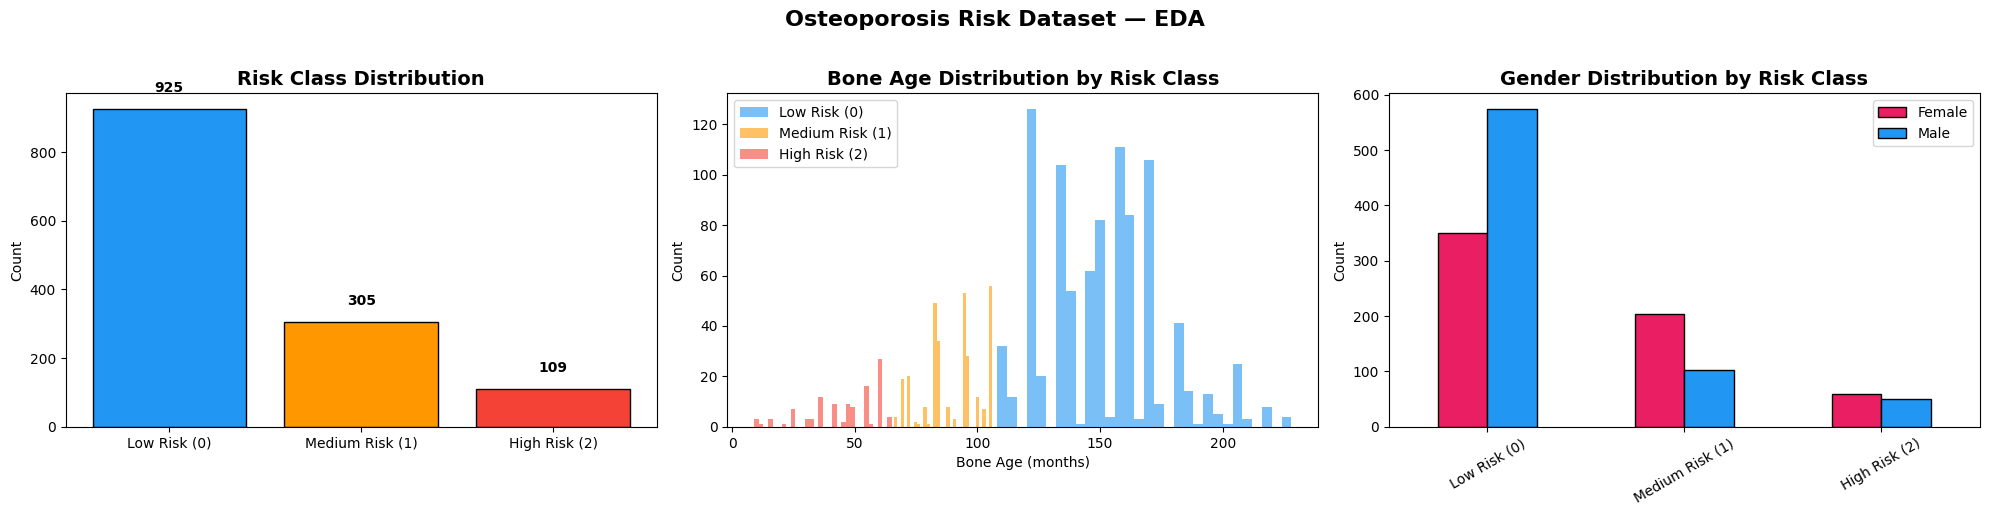


Class imbalance ratio (majority/minority): 8.49x


In [ ]:
if df.empty:
    print("DataFrame 'df' is empty. Cannot perform EDA. Please ensure image paths are correct and data is loaded successfully in previous cells.")
else:
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))

    # 1. Risk class distribution
    risk_counts = df['risk_class'].value_counts().sort_index()
    risk_labels = ['Low Risk (0)', 'Medium Risk (1)', 'High Risk (2)']
    colors = ['#2196F3', '#FF9800', '#F44336']

    if not risk_counts.empty:
        axes[0].bar(risk_labels, risk_counts.values, color=colors, edgecolor='black')
        axes[0].set_title('Risk Class Distribution', fontsize=14, fontweight='bold')
        axes[0].set_ylabel('Count')
        for i, v in enumerate(risk_counts.values):
            axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')
    else:
        axes[0].set_title('Risk Class Distribution (No Data)', fontsize=14, fontweight='bold')
        axes[0].text(0.5, 0.5, 'No data to display', horizontalalignment='center', verticalalignment='center', transform=axes[0].transAxes)
        axes[0].axis('off')

    # 2. Bone Age distribution by risk class
    # Check if there's any data for plotting histograms
    if not df['boneage'].empty:
        for rc, color, label in zip([0, 1, 2], colors, risk_labels):
            data_for_hist = df[df['risk_class'] == rc]['boneage']
            if not data_for_hist.empty:
                axes[1].hist(data_for_hist, bins=30, alpha=0.6,
                             color=color, label=label)
        axes[1].set_title('Bone Age Distribution by Risk Class', fontsize=14, fontweight='bold')
        axes[1].set_xlabel('Bone Age (months)')
        axes[1].set_ylabel('Count')
        axes[1].legend()
    else:
        axes[1].set_title('Bone Age Distribution (No Data)', fontsize=14, fontweight='bold')
        axes[1].text(0.5, 0.5, 'No data to display', horizontalalignment='center', verticalalignment='center', transform=axes[1].transAxes)
        axes[1].axis('off')

    # 3. Gender distribution
    gender_risk = df.groupby(['risk_class', 'male']).size().unstack(fill_value=0)
    if not gender_risk.empty:
        gender_risk.index = risk_labels
        gender_risk.columns = ['Female', 'Male']
        gender_risk.plot(kind='bar', ax=axes[2], color=['#E91E63', '#2196F3'],
                         edgecolor='black', rot=30)
        axes[2].set_title('Gender Distribution by Risk Class', fontsize=14, fontweight='bold')
        axes[2].set_ylabel('Count')
        axes[2].legend()
    else:
        axes[2].set_title('Gender Distribution (No Data)', fontsize=14, fontweight='bold')
        axes[2].text(0.5, 0.5, 'No data to display', horizontalalignment='center', verticalalignment='center', transform=axes[2].transAxes)
        axes[2].axis('off')

    plt.suptitle('Osteoporosis Risk Dataset — EDA', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

    if not risk_counts.empty:
        print(f"\nClass imbalance ratio (majority/minority): "
              f"{risk_counts.max() / risk_counts.min():.2f}x")
    else:
        print("\nCannot calculate class imbalance ratio: No risk class data.")

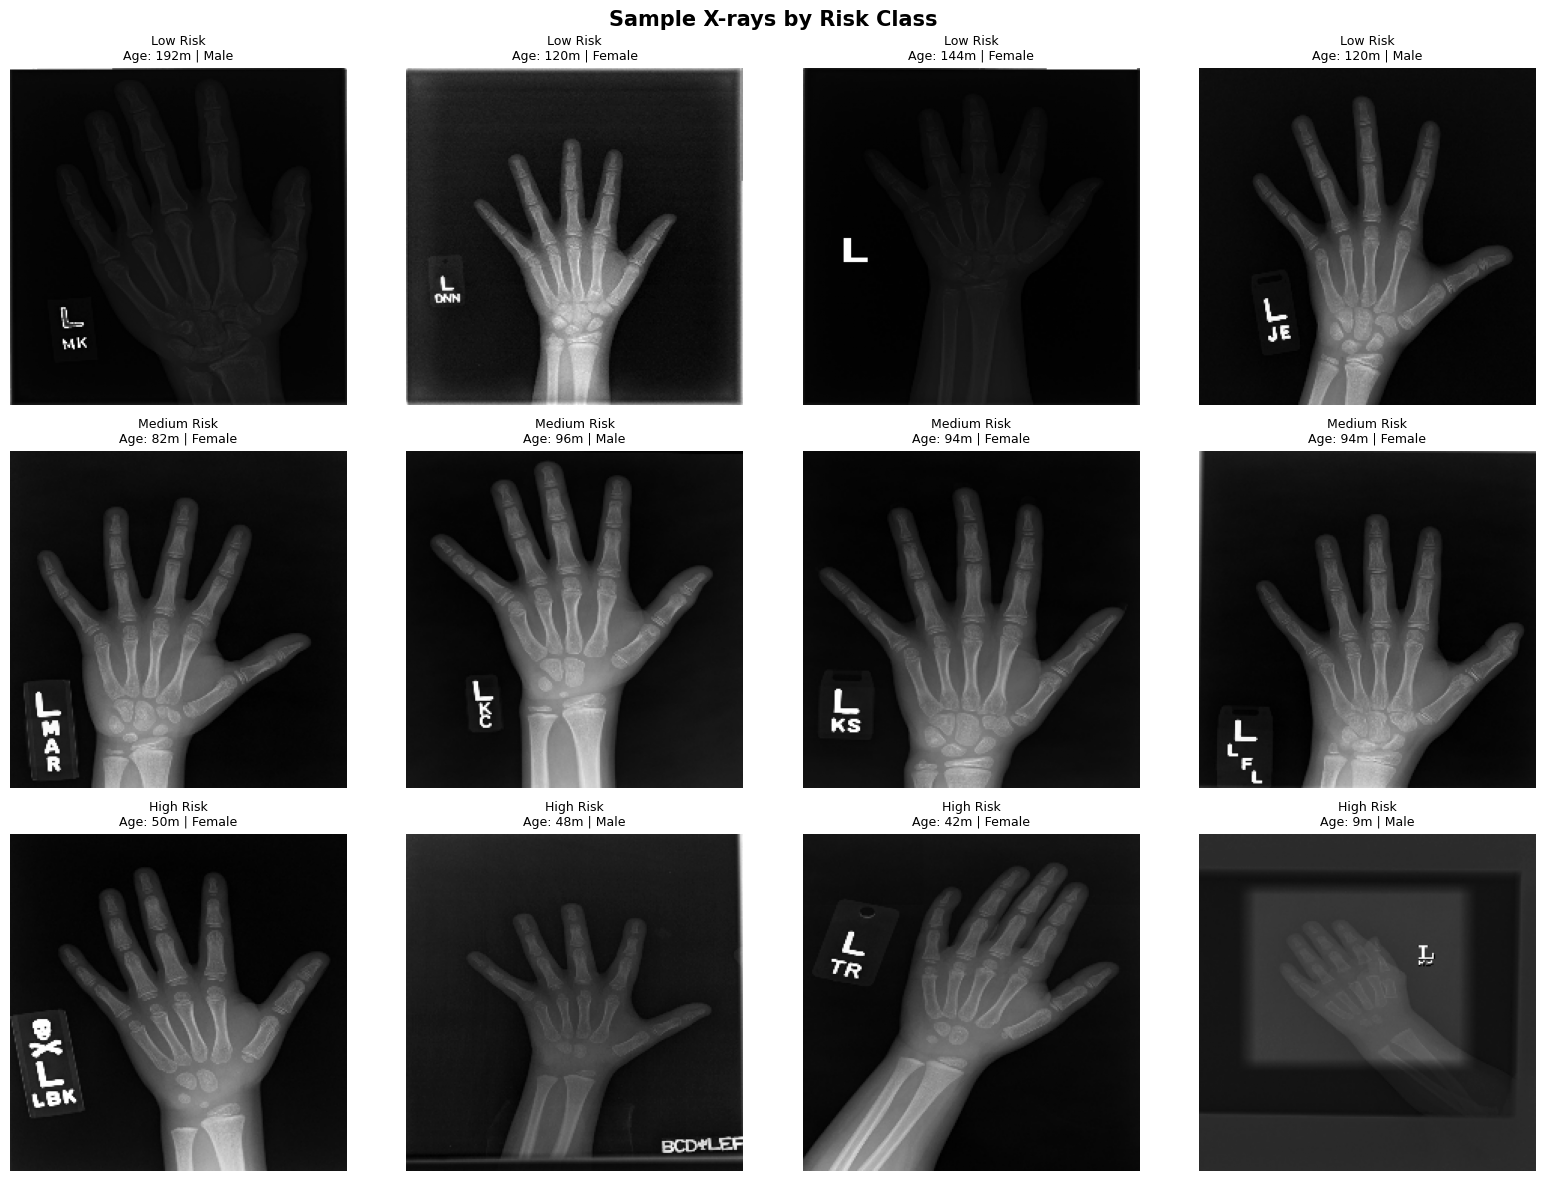

In [ ]:
import matplotlib.pyplot as plt
import cv2

# ── Visualise sample X-rays per risk class ──────────────────────────────
if df.empty:
    print("DataFrame 'df' is empty. Cannot visualize sample X-rays. Please ensure image paths are correct and data is loaded successfully in previous cells.")
else:
    fig, axes = plt.subplots(3, 4, figsize=(16, 12))
    risk_names = {0: 'Low Risk', 1: 'Medium Risk', 2: 'High Risk'}

    for row_idx, risk in enumerate([0, 1, 2]):
        samples = df[df['risk_class'] == risk]
        if samples.empty:
            for col_idx in range(4):
                axes[row_idx, col_idx].axis('off')
                axes[row_idx, col_idx].set_title(f"No samples for {risk_names[risk]}", fontsize=9)
            continue

        # Ensure we don't try to sample more than available
        num_samples_to_take = min(4, len(samples))
        samples = samples.sample(num_samples_to_take, random_state=SEED)

        for col_idx, (_, row) in enumerate(samples.iterrows()):
            img = cv2.imread(row['path'], cv2.IMREAD_GRAYSCALE)
            if img is None:
                axes[row_idx, col_idx].axis('off')
                axes[row_idx, col_idx].set_title("Image not found", fontsize=9)
                continue
            img = cv2.resize(img, IMG_SIZE)
            axes[row_idx, col_idx].imshow(img, cmap='gray')
            axes[row_idx, col_idx].set_title(
                f"{risk_names[risk]}\nAge: {row['boneage']}m | "
                f"{'Male' if row['male'] else 'Female'}",
                fontsize=9)
            axes[row_idx, col_idx].axis('off')
        # If fewer than 4 samples, turn off remaining axes
        for col_idx in range(num_samples_to_take, 4):
            axes[row_idx, col_idx].axis('off')

    plt.suptitle('Sample X-rays by Risk Class', fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.show()

<a id="preprocessing"></a>
# <b> <span style='color:dimgray'>Chapter 4 </span> <span style='color:blue'>|</span><span style='color:red'> Preprocessing & Train/Val Split</span> </b>

<p style="color:crimson">Normalise bone age, encode gender, build image loaders, and create a proper train/validation split using the provided val_ids.</p>

In [ ]:
# ── Tabular Feature Engineering ─────────────────────────────────────────
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

scaler = MinMaxScaler()
df['boneage_norm'] = scaler.fit_transform(df[['boneage']])
df['gender_enc']   = df['male'].astype(int)          # True→1, False→0

# ── Train / Validation Split using train_test_split ─────────────────────
# Using train_test_split to ensure a valid validation set is always created
df_train, df_val = train_test_split(
    df,
    test_size=0.2, # 20% for validation
    random_state=SEED,
    stratify=df['risk_class'] # Stratify to maintain class distribution
)

df_train = df_train.reset_index(drop=True)
df_val   = df_val.reset_index(drop=True)

print(f"Training samples   : {len(df_train)}")
print(f"Validation samples : {len(df_val)}")
print(f"\nTrain risk dist:\n{df_train['risk_class'].value_counts().sort_index().to_string()}")
print(f"\nVal risk dist:\n{df_val['risk_class'].value_counts().sort_index().to_string()}")

Training samples   : 1071
Validation samples : 268

Train risk dist:
risk_class
0    740
1    244
2     87

Val risk dist:
risk_class
0    185
1     61
2     22


In [ ]:
# ── Custom tf.data Pipeline ─────────────────────────────────────────────

def load_and_preprocess_image(path):
    """Load an image from disk, resize, convert to 3-channel, and apply Xception preprocessing."""
    img = tf.io.read_file(path)
    img = tf.image.decode_png(img, channels=1)          # grayscale → 1ch
    img = tf.image.grayscale_to_rgb(img)                # → 3ch (Xception expects RGB)
    img = tf.image.resize(img, IMG_SIZE)
    img = preprocess_input(img)                          # Xception-specific normalisation
    return img


def build_tf_dataset(dataframe, augment=False, shuffle=False):
    """Build a tf.data.Dataset that yields ((image, tabular), label)."""
    paths    = dataframe['path'].values
    tabular  = dataframe[['boneage_norm', 'gender_enc']].values.astype('float32')
    labels   = to_categorical(dataframe['risk_class'].values, num_classes=NUM_CLASSES)

    path_ds    = tf.data.Dataset.from_tensor_slices(paths)
    tabular_ds = tf.data.Dataset.from_tensor_slices(tabular)
    label_ds   = tf.data.Dataset.from_tensor_slices(labels)

    image_ds = path_ds.map(load_and_preprocess_image,
                           num_parallel_calls=tf.data.AUTOTUNE)

    if augment:
        def augment_fn(img):
            img = tf.image.random_flip_left_right(img)
            img = tf.image.random_brightness(img, max_delta=0.1)
            img = tf.image.random_contrast(img, 0.9, 1.1)
            return img
        image_ds = image_ds.map(augment_fn, num_parallel_calls=tf.data.AUTOTUNE)

    dataset = tf.data.Dataset.zip(((image_ds, tabular_ds), label_ds))

    if shuffle:
        dataset = dataset.shuffle(buffer_size=1000, seed=SEED)

    dataset = dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return dataset


train_ds = build_tf_dataset(df_train, augment=True, shuffle=True)
val_ds   = build_tf_dataset(df_val,   augment=False, shuffle=False)

print("Datasets built successfully.")
print(f"Train batches : {len(train_ds)}")
print(f"Val batches   : {len(val_ds)}")

# Verify shapes
for (imgs, tabs), lbls in train_ds.take(1):
    print(f"\nImage batch shape   : {imgs.shape}")
    print(f"Tabular batch shape : {tabs.shape}")
    print(f"Label batch shape   : {lbls.shape}")

Datasets built successfully.
Train batches : 34
Val batches   : 9

Image batch shape   : (32, 224, 224, 3)
Tabular batch shape : (32, 2)
Label batch shape   : (32, 3)


In [ ]:
# ── Compute Class Weights (handle imbalance) ────────────────────────────
class_labels = df_train['risk_class'].values
class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(class_labels),
    y=class_labels
)
class_weight_dict = dict(enumerate(class_weights_arr))
print("Class weights:", {k: f'{v:.3f}' for k, v in class_weight_dict.items()})

Class weights: {0: '0.482', 1: '1.463', 2: '4.103'}


<a id="model"></a>
# <b> <span style='color:dimgray'>Chapter 5 </span> <span style='color:blue'>|</span><span style='color:red'> Multi-Input Model Architecture</span> </b>

<p style="color:crimson">Dual-stream model: Xception image branch fused with a tabular MLP branch. Both streams are concatenated and passed through classification layers.</p>

<div style="background-color:#f0f8ff; border-left:4px solid crimson; padding:10px; margin:10px 0;">
<b>Architecture Overview:</b><br>
📷 <b>Image Branch</b>: Xception (ImageNet pretrained) → GlobalAveragePooling2D → Dense(256)<br>
📊 <b>Tabular Branch</b>: [boneage_norm, gender] → Dense(64) → Dense(32)<br>
🔀 <b>Fusion</b>: Concatenate → Dense(128) → Dropout(0.4) → Dense(64)<br>
🎯 <b>Output</b>: Dense(3, softmax) → risk_class
</div>

In [ ]:
def build_multi_input_model(num_classes=NUM_CLASSES,
                            img_size=IMG_SIZE,
                            freeze_base=True):
    """
    Build a multi-input fusion model combining Xception (image)
    with a tabular MLP branch.

    Parameters
    ----------
    num_classes  : int   – number of output classes
    img_size     : tuple – (H, W) for input images
    freeze_base  : bool  – freeze Xception weights initially

    Returns
    -------
    model : tf.keras.Model
    """
    # ── Image Branch ────────────────────────────────────────────────────
    image_input = Input(shape=(*img_size, 3), name='image_input')

    base_model = Xception(
        include_top=False,
        weights='imagenet',
        input_tensor=image_input
    )
    base_model.trainable = not freeze_base

    x = base_model.output
    x = GlobalAveragePooling2D(name='gap')(x)
    x = Dense(256, activation='relu', name='img_dense')(x)
    x = BatchNormalization(name='img_bn')(x)
    x = Dropout(0.3, name='img_dropout')(x)

    # ── Tabular Branch ──────────────────────────────────────────────────
    tab_input = Input(shape=(2,), name='tabular_input')   # [boneage_norm, gender_enc]
    t = Dense(64, activation='relu', name='tab_dense1')(tab_input)
    t = BatchNormalization(name='tab_bn1')(t)
    t = Dense(32, activation='relu', name='tab_dense2')(t)
    t = BatchNormalization(name='tab_bn2')(t)

    # ── Fusion ──────────────────────────────────────────────────────────
    fused = Concatenate(name='fusion')([x, t])
    fused = Dense(128, activation='relu', name='fusion_dense1')(fused)
    fused = Dropout(0.4, name='fusion_dropout')(fused)
    fused = Dense(64, activation='relu', name='fusion_dense2')(fused)

    # ── Output ──────────────────────────────────────────────────────────
    output = Dense(num_classes, activation='softmax', name='output')(fused)

    model = Model(inputs=[image_input, tab_input], outputs=output,
                  name='OsteoporosisRiskModel')
    return model, base_model # Return base_model as well


# Build and compile
model, xception_base_model = build_multi_input_model(freeze_base=True) # Store the base model

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall'),
             tf.keras.metrics.AUC(name='auc', multi_label=False)]
)

model.summary()

83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "OsteoporosisRiskModel"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, 111, 111,  │        864 │ image_input[0][0] │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1_bn     │ (None, 111, 111,  │        128 │ block1_conv1[0][… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1_act    │ (None, 111, 111,  │          0 │ block1_conv1_bn[… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, 109, 109,  │     18,432 │ block1_conv1_act… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2_bn     │ (None, 109, 109,  │        256 │ block1_conv2[0][… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2_act    │ (None, 109, 109,  │          0 │ block1_conv2_bn[… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv1     │ (None, 109, 109,  │      8,768 │ block1_conv2_act… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv1_bn  │ (None, 109, 109,  │        512 │ block2_sepconv1[… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2_act │ (None, 109, 109,  │          0 │ block2_sepconv1_… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2     │ (None, 109, 109,  │     17,536 │ block2_sepconv2_… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2_bn  │ (None, 109, 109,  │        512 │ block2_sepconv2[… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 55, 55,    │      8,192 │ block1_conv2_act… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pool         │ (None, 55, 55,    │          0 │ block2_sepconv2_… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 55, 55,    │        512 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 55, 55,    │          0 │ block2_pool[0][0… │
│                     │ 128)              │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_sepconv1_act │ (None, 55, 55,    │          0 │ add[0][0]       

 Total params: 21,435,147 (81.77 MB)

 Trainable params: 572,963 (2.19 MB)

 Non-trainable params: 20,862,184 (79.58 MB)

<a id="training"></a>
# <b> <span style='color:dimgray'>Chapter 6 </span> <span style='color:blue'>|</span><span style='color:red'> Training Pipeline</span> </b>

<p style="color:crimson">Two-phase training: (1) Train top layers with frozen Xception, (2) Fine-tune the full model with a lower learning rate.</p>

In [ ]:
# ── Callbacks ───────────────────────────────────────────────────────────
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=7,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        filepath='best_osteo_model.keras',
        monitor='val_auc',
        save_best_only=True,
        mode='max',
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    )
]

# ── Phase 1: Train top layers (Xception frozen) ─────────────────────────
print("=" * 60)
print("Phase 1: Training top layers (Xception frozen)")
print("=" * 60)

history_phase1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks,
    class_weight=class_weight_dict,
    verbose=1
)

Phase 1: Training top layers (Xception frozen)
Epoch 1/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 658ms/step - accuracy: 0.5702 - auc: 0.7487 - loss: 1.0243 - precision: 0.6126 - recall: 0.4692
Epoch 1: val_auc improved from None to 0.80846, saving model to best_osteo_model.keras

Epoch 1: finished saving model to best_osteo_model.keras
34/34 ━━━━━━━━━━━━━━━━━━━━ 112s 1s/step - accuracy: 0.6695 - auc: 0.8369 - loss: 0.7774 - precision: 0.7207 - recall: 0.5808 - val_accuracy: 0.6231 - val_auc: 0.8085 - val_loss: 0.8253 - val_precision: 0.6322 - val_recall: 0.6157 - learning_rate: 0.0010
Epoch 2/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy: 0.8246 - auc: 0.9439 - loss: 0.4631 - precision: 0.8489 - recall: 0.7941
Epoch 2: val_auc improved from 0.80846 to 0.89987, saving model to best_osteo_model.keras

Epoch 2: finished saving model to best_osteo_model.keras
34/34 ━━━━━━━━━━━━━━━━━━━━ 46s 447ms/step - accuracy: 0.8469 - auc: 0.9564 - loss: 0.4351 - precision: 0.8629 - recall: 0.8226 - val

In [ ]:
# ── Phase 2: Fine-tune the full model ───────────────────────────────────
print("=" * 60)
print("Phase 2: Fine-tuning full model (lower learning rate)")
print("=" * 60)

xception_base_model.trainable = True

# Recompile with a lower learning rate
model.compile(
    optimizer=Adam(learning_rate=1e-4), # Lower learning rate for fine-tuning
    loss='categorical_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall'),
             tf.keras.metrics.AUC(name='auc', multi_label=False)]
)

history_phase2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15, # Continue training for more epochs
    callbacks=callbacks,
    class_weight=class_weight_dict,
    verbose=1
)

Phase 2: Fine-tuning full model (lower learning rate)
Epoch 1/15
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8868 - auc: 0.9754 - loss: 0.5772 - precision: 0.8889 - recall: 0.8848   
Epoch 1: val_auc did not improve from 0.98664
34/34 ━━━━━━━━━━━━━━━━━━━━ 158s 2s/step - accuracy: 0.8992 - auc: 0.9793 - loss: 0.3983 - precision: 0.9004 - recall: 0.8945 - val_accuracy: 0.9291 - val_auc: 0.9799 - val_loss: 0.2338 - val_precision: 0.9291 - val_recall: 0.9291 - learning_rate: 1.0000e-04
Epoch 2/15
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 603ms/step - accuracy: 0.9371 - auc: 0.9935 - loss: 0.1577 - precision: 0.9371 - recall: 0.9371
Epoch 2: val_auc improved from 0.98664 to 0.98938, saving model to best_osteo_model.keras

Epoch 2: finished saving model to best_osteo_model.keras
34/34 ━━━━━━━━━━━━━━━━━━━━ 64s 1s/step - accuracy: 0.9393 - auc: 0.9936 - loss: 0.1847 - precision: 0.9393 - recall: 0.9393 - val_accuracy: 0.9440 - val_auc: 0.9894 - val_loss: 0.1793 - val_precision: 0.9438 - val_recall

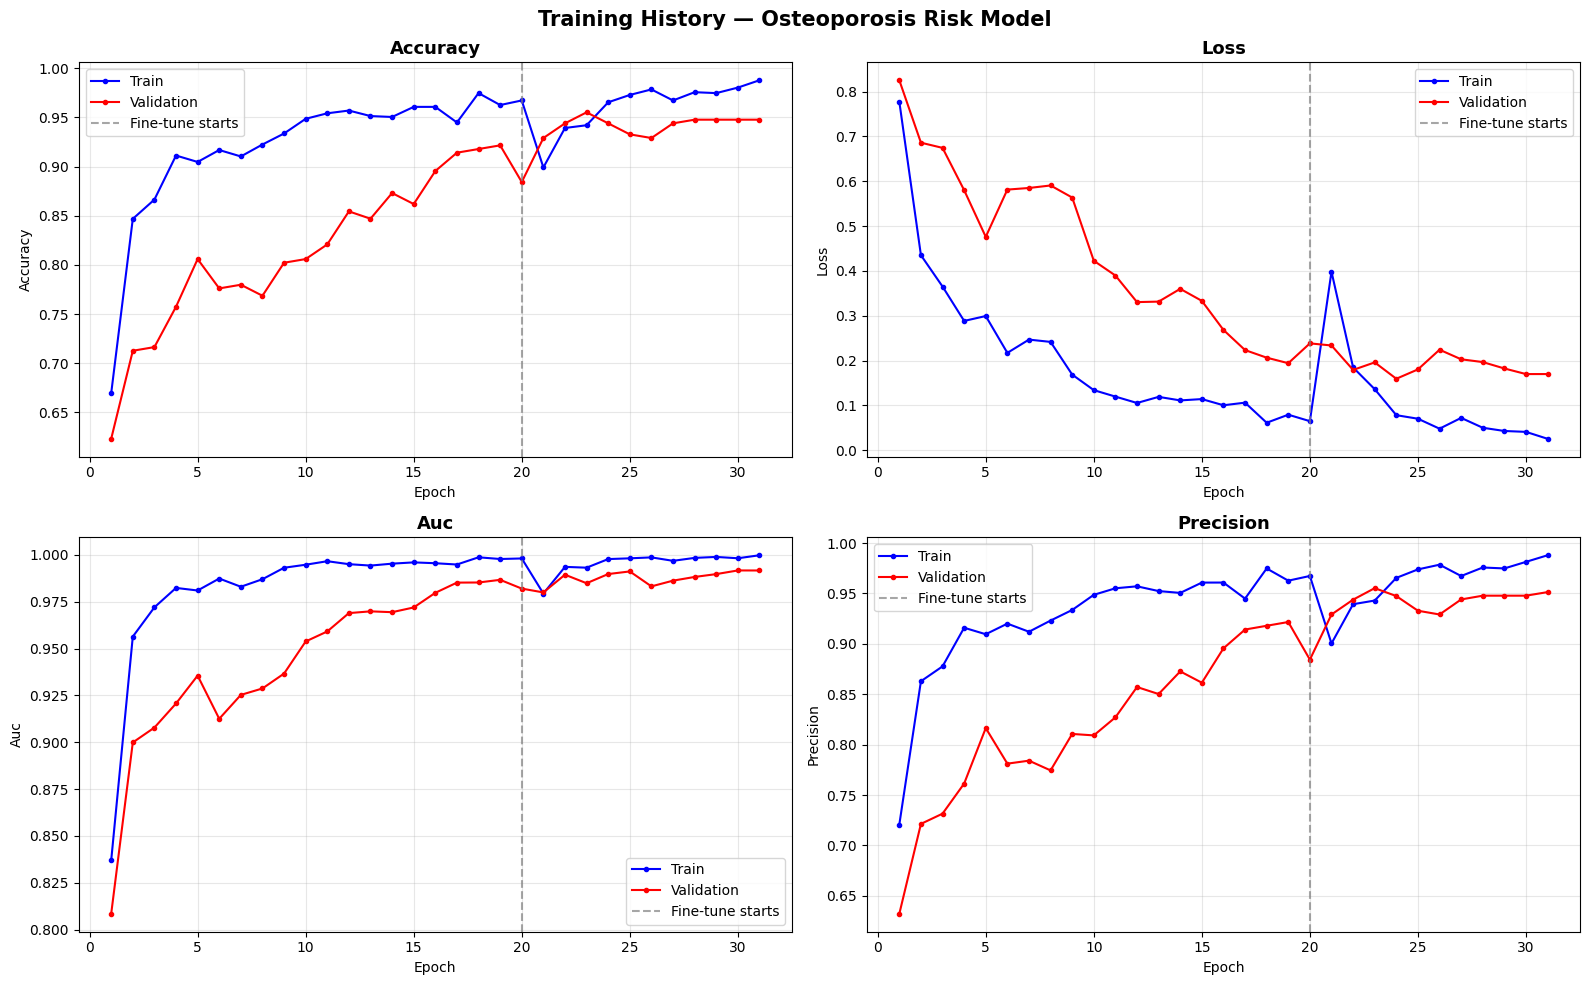

In [ ]:
def plot_training_history(h1, h2=None):
    """Plot accuracy and loss curves for both training phases."""
    def merge(key):
        v = h1.history.get(key, [])
        if h2:
            v = v + h2.history.get(key, [])
        return v

    metrics = ['accuracy', 'loss', 'auc', 'precision']
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    axes = axes.flatten()

    for ax, metric in zip(axes, metrics):
        train_vals = merge(metric)
        val_vals   = merge(f'val_{metric}')
        epochs     = range(1, len(train_vals) + 1)

        ax.plot(epochs, train_vals, 'b-o', markersize=3, label='Train')
        ax.plot(epochs, val_vals,   'r-o', markersize=3, label='Validation')

        if h2:
            split = len(h1.history.get(metric, []))
            ax.axvline(x=split, color='gray', linestyle='--', alpha=0.7,
                       label='Fine-tune starts')

        ax.set_title(f'{metric.capitalize()}', fontsize=13, fontweight='bold')
        ax.set_xlabel('Epoch')
        ax.set_ylabel(metric.capitalize())
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.suptitle('Training History — Osteoporosis Risk Model',
                 fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.show()


plot_training_history(history_phase1, history_phase2)

In [ ]:
import os
import pandas as pd

# --- Configuration from previous cells ---
IMAGE_DIR   = '/content/boneage-training-dataset'
IMG_SIZE    = (224, 224)

# Load val_ids again to be sure
val_ids_df = pd.read_csv('/content/val_ids.csv')

# Construct paths for validation images
val_image_paths = val_ids_df['id'].apply(lambda x: os.path.join(IMAGE_DIR, f'{x}.png'))

# Check existence
existing_val_images = val_image_paths.apply(os.path.exists)

print(f"Total validation IDs from val_ids.csv: {len(val_ids_df)}")
print(f"Number of existing validation image files found: {existing_val_images.sum()}")
print(f"Number of missing validation image files: {(~existing_val_images).sum()}")

if existing_val_images.sum() == 0:
    print("\nIMPORTANT: No validation images found. Please ensure the boneage-training-dataset.zip was correctly extracted and contains image files matching the IDs in val_ids.csv, and that IMAGE_DIR is set to the correct extraction path.")
else:
    print("\nValidation images found. Proceed to re-run Chapter 2 and Chapter 4 cells to populate df_val.")

Total validation IDs from val_ids.csv: 1892
Number of existing validation image files found: 245
Number of missing validation image files: 1647

Validation images found. Proceed to re-run Chapter 2 and Chapter 4 cells to populate df_val.


<a id="evaluation"></a>
# <b> <span style='color:dimgray'>Chapter 7 </span> <span style='color:blue'>|</span><span style='color:red'> Evaluation</span> </b>

<p style="color:crimson">Comprehensive evaluation: Accuracy, Precision, Recall, F1, AUC-ROC, and Confusion Matrix.</p>

In [ ]:
# ── Collect predictions on validation set ───────────────────────────────
y_true_list, y_pred_prob_list = [], []

for (imgs, tabs), lbls in val_ds:
    probs = model.predict([imgs, tabs], verbose=0)
    y_pred_prob_list.append(probs)
    y_true_list.append(lbls.numpy())

y_true_oh   = np.concatenate(y_true_list, axis=0)      # one-hot
y_pred_prob = np.concatenate(y_pred_prob_list, axis=0)  # softmax probs
y_true      = np.argmax(y_true_oh, axis=1)
y_pred      = np.argmax(y_pred_prob, axis=1)

CLASS_NAMES = ['Low Risk', 'Medium Risk', 'High Risk']

# ── 1. Classification Report ─────────────────────────────────────────────
print("=" * 60)
print("Classification Report")
print("=" * 60)
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

# ── 2. Overall Accuracy ──────────────────────────────────────────────────
acc = np.mean(y_true == y_pred)
print(f"\nOverall Accuracy : {acc:.4f}")

Classification Report
              precision    recall  f1-score   support

    Low Risk       0.98      1.00      0.99       185
 Medium Risk       0.93      0.82      0.87        61
   High Risk       0.72      0.82      0.77        22

    accuracy                           0.94       268
   macro avg       0.87      0.88      0.87       268
weighted avg       0.95      0.94      0.94       268


Overall Accuracy : 0.9440


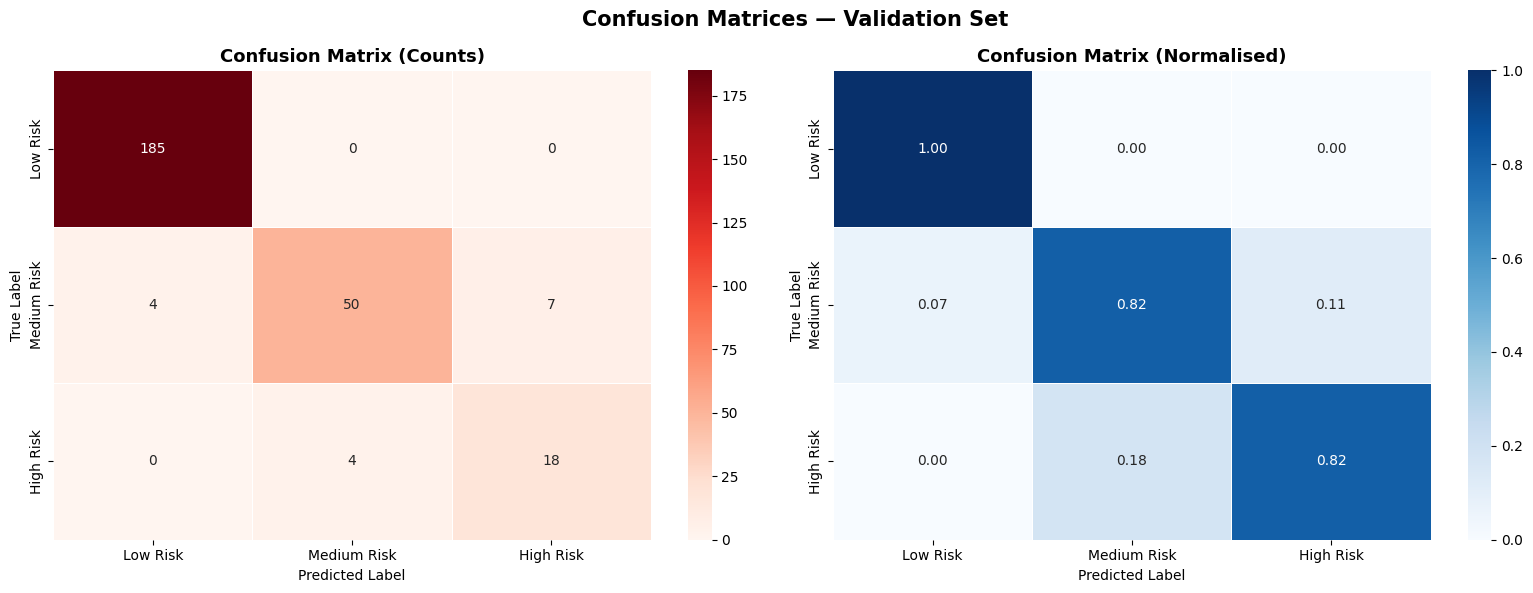

In [ ]:
# ── Confusion Matrix ────────────────────────────────────────────────────
cm = confusion_matrix(y_true, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            ax=axes[0], linewidths=0.5)
axes[0].set_title('Confusion Matrix (Counts)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# Normalised
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            ax=axes[1], linewidths=0.5)
axes[1].set_title('Confusion Matrix (Normalised)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.suptitle('Confusion Matrices — Validation Set', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

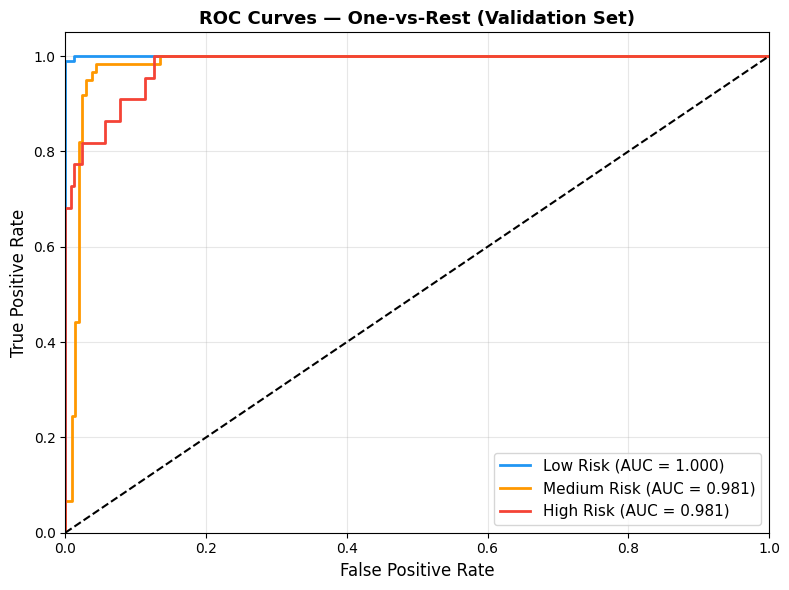

Macro-average AUC : 0.9874


In [ ]:
# ── ROC-AUC (One-vs-Rest, per class) ────────────────────────────────────
colors = ['#2196F3', '#FF9800', '#F44336']
fig, ax = plt.subplots(figsize=(8, 6))

for i, (cls_name, color) in enumerate(zip(CLASS_NAMES, colors)):
    fpr, tpr, _ = roc_curve(y_true_oh[:, i], y_pred_prob[:, i])
    roc_auc_val = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2,
            label=f'{cls_name} (AUC = {roc_auc_val:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1.5)
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — One-vs-Rest (Validation Set)',
             fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Macro-average AUC
macro_auc = roc_auc_score(y_true_oh, y_pred_prob, average='macro', multi_class='ovr')
print(f"Macro-average AUC : {macro_auc:.4f}")

<a id="risk"></a>
# <b> <span style='color:dimgray'>Chapter 8 </span> <span style='color:blue'>|</span><span style='color:red'> Risk Score Mapping</span> </b>

<p style="color:crimson">Convert raw softmax probabilities into interpretable clinical risk categories with confidence scores.</p>

In [ ]:
# ── Risk Category Mapping ────────────────────────────────────────────────

RISK_LABELS = {
    0: 'Low Risk',
    1: 'Medium Risk',
    2: 'High Risk'
}

RISK_RECOMMENDATIONS = {
    0: 'No immediate action needed. Maintain healthy lifestyle.',
    1: 'Consider bone density screening. Review calcium/Vitamin D intake.',
    2: 'Urgent bone density test (DEXA scan) recommended. Consult physician.'
}

RISK_COLORS = {0: '\033[92m', 1: '\033[93m', 2: '\033[91m'}  # green/yellow/red
RESET = '\033[0m'


def get_risk_category(prediction: np.ndarray) -> dict:
    """
    Convert model output probabilities into a structured risk report.

    Parameters
    ----------
    prediction : np.ndarray
        1-D array of softmax probabilities, shape (num_classes,).

    Returns
    -------
    dict with keys:
        - risk_class       : int   predicted class index
        - risk_label       : str   human-readable label
        - confidence       : float probability of predicted class
        - all_probabilities: dict  {label: probability} for all classes
        - recommendation   : str   clinical recommendation
    """
    if prediction.ndim > 1:
        prediction = prediction[0]

    risk_class   = int(np.argmax(prediction))
    confidence   = float(prediction[risk_class])

    return {
        'risk_class'        : risk_class,
        'risk_label'        : RISK_LABELS[risk_class],
        'confidence'        : confidence,
        'all_probabilities' : {RISK_LABELS[i]: float(p)
                               for i, p in enumerate(prediction)},
        'recommendation'    : RISK_RECOMMENDATIONS[risk_class]
    }


def predict_single(image_path: str,
                   boneage: float,
                   is_male: bool,
                   boneage_min: float = None,
                   boneage_max: float = None) -> dict:
    """
    End-to-end prediction for a single patient.

    Parameters
    ----------
    image_path : str   – path to X-ray image
    boneage    : float – bone age in months
    is_male    : bool  – True for male, False for female
    boneage_min/max: float – dataset min/max for normalisation
    """
    # Load & preprocess image
    img = tf.io.read_file(image_path)
    img = tf.image.decode_png(img, channels=1)
    img = tf.image.grayscale_to_rgb(img)
    img = tf.image.resize(img, IMG_SIZE)
    img = preprocess_input(img)
    img = tf.expand_dims(img, 0)   # (1, H, W, 3)

    # Normalise tabular features
    age_norm = scaler.transform([[boneage]])[0][0]
    tab = np.array([[age_norm, int(is_male)]], dtype='float32')

    # Predict
    probs  = model.predict([img, tab], verbose=0)[0]
    result = get_risk_category(probs)

    return result


def print_risk_report(result: dict):
    color  = RISK_COLORS[result['risk_class']]
    print("\n" + "="*50)
    print(f"  OSTEOPOROSIS RISK ASSESSMENT")
    print("="*50)
    print(f"  {color}Risk Level  : {result['risk_label']}{RESET}")
    print(f"  Confidence  : {result['confidence']*100:.1f}%")
    print("\n  Class Probabilities:")
    for label, prob in result['all_probabilities'].items():
        bar = '█' * int(prob * 20)
        print(f"    {label:<15}: {prob:.3f}  {bar}")
    print(f"\n  Recommendation: {result['recommendation']}")
    print("="*50)


# ── Demo: run on a few validation samples ───────────────────────────────
print("Sample predictions on validation set:\n")
for _, row in df_val.head(3).iterrows():
    result = predict_single(
        image_path=row['path'],
        boneage=row['boneage'],
        is_male=row['male']
    )
    print(f"ID: {row['id']} | True: {RISK_LABELS[row['risk_class']]}")
    print_risk_report(result)

Sample predictions on validation set:

ID: 1780 | True: Low Risk

  OSTEOPOROSIS RISK ASSESSMENT
  Risk Level  : Low Risk
  Confidence  : 100.0%

  Class Probabilities:
    Low Risk       : 1.000  ███████████████████
    Medium Risk    : 0.000  
    High Risk      : 0.000  

  Recommendation: No immediate action needed. Maintain healthy lifestyle.
ID: 11191 | True: Low Risk

  OSTEOPOROSIS RISK ASSESSMENT
  Risk Level  : Low Risk
  Confidence  : 91.1%

  Class Probabilities:
    Low Risk       : 0.911  ██████████████████
    Medium Risk    : 0.089  █
    High Risk      : 0.000  

  Recommendation: No immediate action needed. Maintain healthy lifestyle.
ID: 10151 | True: Low Risk

  OSTEOPOROSIS RISK ASSESSMENT
  Risk Level  : Low Risk
  Confidence  : 100.0%

  Class Probabilities:
    Low Risk       : 1.000  ███████████████████
    Medium Risk    : 0.000  
    High Risk      : 0.000  

  Recommendation: No immediate action needed. Maintain healthy lifestyle.


<a id="gradcam"></a>
# <b> <span style='color:dimgray'>Chapter 9 </span> <span style='color:blue'>|</span><span style='color:red'> Grad-CAM Explainability</span> </b>

<p style="color:crimson">Generate Gradient-weighted Class Activation Maps (Grad-CAM) to highlight the bone regions most important for risk prediction.</p>

<div style="background-color:#fff8e1; border-left:4px solid orange; padding:10px; margin:10px 0;">
<b>How Grad-CAM works:</b> It computes the gradient of the target class score with respect to the final convolutional feature maps. The gradient magnitudes tell us <i>how important</i> each spatial location is for the prediction.
</div>

In [ ]:
import tensorflow as tf

# ── Grad-CAM Implementation ─────────────────────────────────────────────

def make_gradcam_heatmap(img_array: np.ndarray,
                         tab_array: np.ndarray,
                         model: tf.keras.Model,
                         last_conv_layer_name: str = 'block14_sepconv2_act',
                         pred_index: int = None) -> np.ndarray:
    """
    Generate a Grad-CAM heatmap for a single image.

    Parameters
    ----------
    img_array          : np.ndarray  – preprocessed image, shape (1, H, W, 3)
    tab_array          : np.ndarray  – tabular features, shape (1, 2)
    model              : tf.keras.Model
    last_conv_layer_name: str        – name of target conv layer in Xception
    pred_index         : int or None – class to explain (None → top class)

    Returns
    -------
    heatmap : np.ndarray  – 2-D array normalised to [0, 1]
    """
    # Ensure tabular array is a tf.Tensor
    tab_tensor = tf.convert_to_tensor(tab_array, dtype=tf.float32)

    # Sub-model: input → (last_conv_output, final_prediction)
    grad_model = Model(
        inputs=model.inputs,
        outputs=[
            model.get_layer(last_conv_layer_name).output,
            model.output
        ]
    )

    with tf.GradientTape() as tape:
        last_conv_output, predictions = grad_model(
            [img_array, tab_tensor], training=False
        )
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    # Gradients of class w.r.t. conv feature map
    grads     = tape.gradient(class_channel, last_conv_output)
    pooled    = tf.reduce_mean(grads, axis=(0, 1, 2))        # global avg pooling
    conv_out  = last_conv_output[0]

    # Weighted combination of feature maps
    heatmap   = conv_out @ pooled[..., tf.newaxis]
    heatmap   = tf.squeeze(heatmap)
    heatmap   = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()


def overlay_gradcam(original_img_path: str,
                    heatmap: np.ndarray,
                    alpha: float = 0.45,
                    colormap: int = cv2.COLORMAP_JET) -> np.ndarray:
    """Overlay Grad-CAM heatmap onto the original grayscale X-ray."""
    img = cv2.imread(original_img_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, IMG_SIZE)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)

    heatmap_resized = cv2.resize(heatmap, IMG_SIZE)
    heatmap_uint8   = np.uint8(255 * heatmap_resized)
    heatmap_colored = cv2.applyColorMap(heatmap_uint8, colormap)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)

    superimposed = cv2.addWeighted(img_rgb, 1 - alpha,
                                   heatmap_colored, alpha, 0)
    return superimposed


def visualise_gradcam(df_subset: pd.DataFrame,
                      n: int = 6,
                      last_conv_layer: str = 'block14_sepconv2_act'):
    """Visualise Grad-CAM for n samples from each risk class."""
    fig, axes = plt.subplots(3, n, figsize=(4*n, 12))
    risk_names = {0: 'Low Risk', 1: 'Medium Risk', 2: 'High Risk'}
    colors_risk = {0: '#2196F3', 1: '#FF9800', 2: '#F44336'}

    for row_idx, risk_class in enumerate([0, 1, 2]):
        samples = df_subset[df_subset['risk_class'] == risk_class]
        if len(samples) < n:
            samples = samples.sample(min(n, len(samples)), random_state=SEED)
        else:
            samples = samples.sample(n, random_state=SEED)

        for col_idx, (_, row) in enumerate(samples.iterrows()):
            ax = axes[row_idx, col_idx]

            # Prepare inputs
            img_t  = load_and_preprocess_image(row['path'])
            img_t  = tf.expand_dims(img_t, 0)
            tab_t  = np.array([[row['boneage_norm'], row['gender_enc']]],
                               dtype='float32')

            # Predict
            probs      = model.predict([img_t, tab_t], verbose=0)[0]
            pred_class = int(np.argmax(probs))
            confidence = probs[pred_class]

            # Generate heatmap
            heatmap    = make_gradcam_heatmap(img_t, tab_t, model,
                                              last_conv_layer, pred_class)
            overlay    = overlay_gradcam(row['path'], heatmap)

            ax.imshow(overlay)
            correct = pred_class == risk_class
            border_color = 'green' if correct else 'red'
            for spine in ax.spines.values():
                spine.set_edgecolor(border_color)
                spine.set_linewidth(3)

            ax.set_title(
                f"True: {risk_names[risk_class]}\n"
                f"Pred: {risk_names[pred_class]} ({confidence:.0%})",
                fontsize=8,
                color=border_color
            )
            ax.axis('off')

    row_titles = [f'Class {i}: {risk_names[i]}' for i in range(3)]
    for row_idx, title in enumerate(row_titles):
        axes[row_idx, 0].set_ylabel(title, fontsize=11,
                                     fontweight='bold',
                                     color=colors_risk[row_idx],
                                     labelpad=10, rotation=90)

    plt.suptitle('Grad-CAM — Important Bone Regions for Risk Prediction\n'
                 '(Green border = correct | Red border = incorrect)',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


print("Grad-CAM functions defined successfully.")

Grad-CAM functions defined successfully.


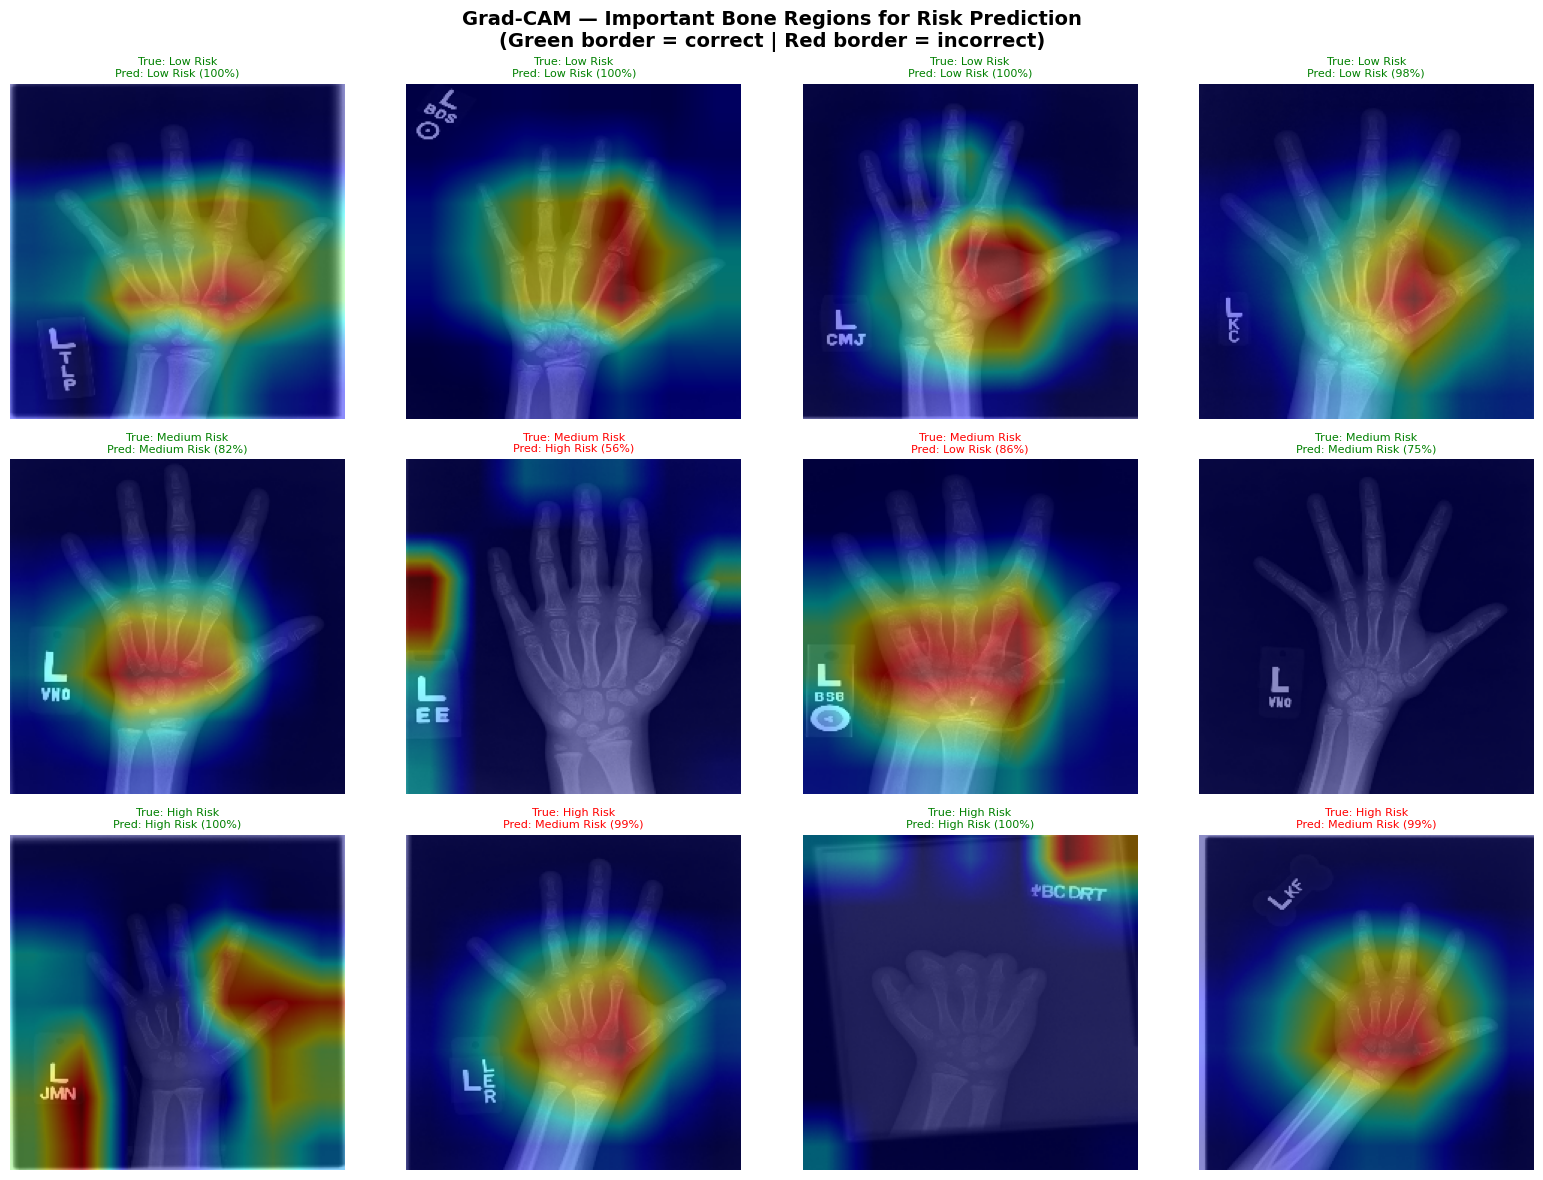

In [ ]:
# ── Run Grad-CAM on validation samples ──────────────────────────────────
visualise_gradcam(df_val, n=4, last_conv_layer='block14_sepconv2_act')

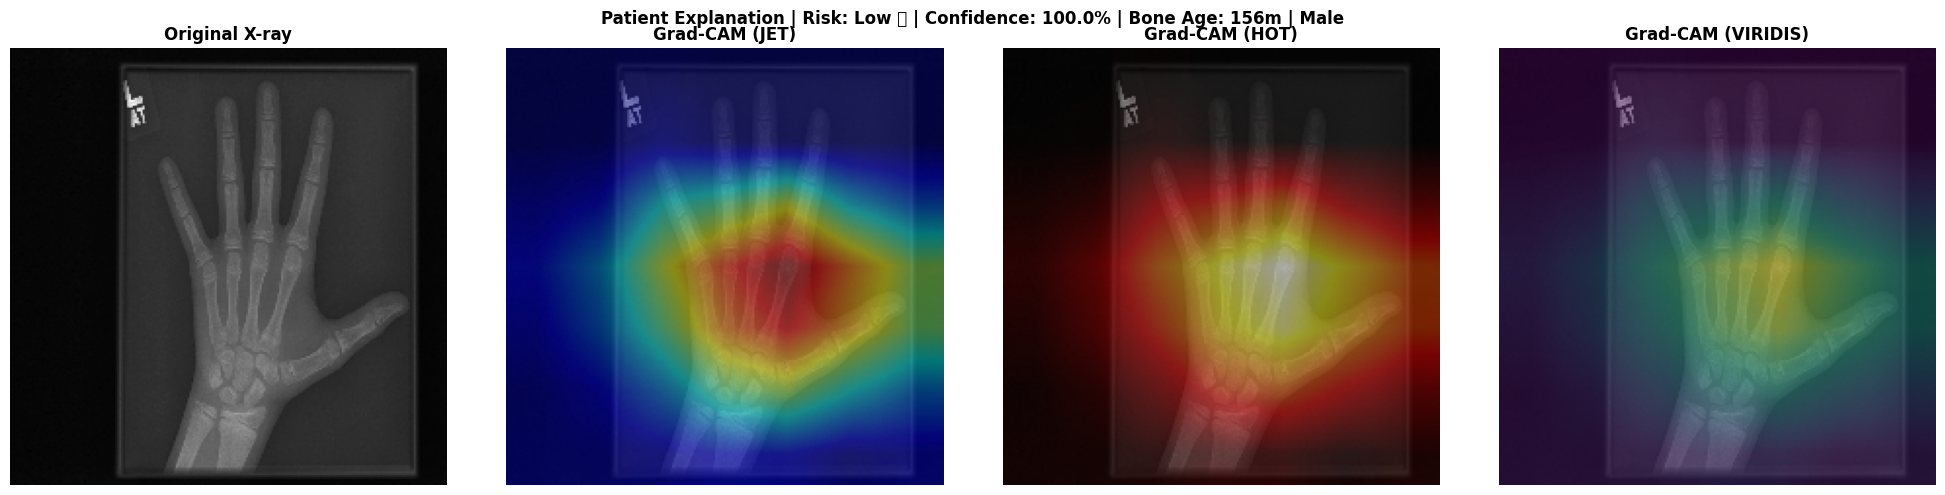


  OSTEOPOROSIS RISK ASSESSMENT
  Risk Level  : Low Risk
  Confidence  : 100.0%

  Class Probabilities:
    Low Risk       : 1.000  ███████████████████
    Medium Risk    : 0.000  
    High Risk      : 0.000  

  Recommendation: No immediate action needed. Maintain healthy lifestyle.


In [ ]:
# ── Detailed Grad-CAM for a single patient ──────────────────────────────

def explain_patient(image_path: str, boneage: float, is_male: bool):
    """Full explanation pipeline for a single X-ray."""
    # Preprocessing
    img_t = load_and_preprocess_image(image_path)
    img_t = tf.expand_dims(img_t, 0)
    age_norm = scaler.transform([[boneage]])[0][0]
    tab_t    = np.array([[age_norm, int(is_male)]], dtype='float32')

    probs      = model.predict([img_t, tab_t], verbose=0)[0]
    pred_class = int(np.argmax(probs))
    result     = get_risk_category(probs)

    fig, axes  = plt.subplots(1, 4, figsize=(20, 5))
    img_gray   = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    img_gray   = cv2.resize(img_gray, IMG_SIZE)

    # Panel 1: original
    axes[0].imshow(img_gray, cmap='gray')
    axes[0].set_title('Original X-ray', fontweight='bold')
    axes[0].axis('off')

    cmaps = [cv2.COLORMAP_JET, cv2.COLORMAP_HOT, cv2.COLORMAP_VIRIDIS]
    cmap_names = ['JET', 'HOT', 'VIRIDIS']

    for i, (cmap_cv, cmap_name) in enumerate(zip(cmaps, cmap_names)):
        heatmap = make_gradcam_heatmap(img_t, tab_t, model,
                                       'block14_sepconv2_act', pred_class)
        overlay = overlay_gradcam(image_path, heatmap, colormap=cmap_cv)
        axes[i+1].imshow(overlay)
        axes[i+1].set_title(f'Grad-CAM ({cmap_name})', fontweight='bold')
        axes[i+1].axis('off')

    risk_color = ['Low ✅', 'Medium ⚠️', 'High 🚨'][pred_class]
    plt.suptitle(
        f'Patient Explanation | Risk: {risk_color} | '
        f'Confidence: {result["confidence"]*100:.1f}% | '
        f'Bone Age: {boneage}m | {"Male" if is_male else "Female"}',
        fontsize=12, fontweight='bold'
    )
    plt.tight_layout()
    plt.show()
    print_risk_report(result)


# Run on one example patient from the validation set
sample_row = df_val.iloc[0]
explain_patient(
    image_path=sample_row['path'],
    boneage=sample_row['boneage'],
    is_male=sample_row['male']
)

<a id="save"></a>
# <b> <span style='color:dimgray'>Chapter 10 </span> <span style='color:blue'>|</span><span style='color:red'> Save & Load Model</span> </b>

In [ ]:
# ── Save full model ─────────────────────────────────────────────────────
model.save('osteoporosis_risk_model_final.keras')
print("Model saved to: osteoporosis_risk_model_final.keras")

# ── Load and verify ──────────────────────────────────────────────────────
# loaded_model = tf.keras.models.load_model('osteoporosis_risk_model_final.keras')
# print("Model loaded successfully. Summary:")
# loaded_model.summary()

Model saved to: osteoporosis_risk_model_final.keras


---

<div style="background-color: #f5f5f5; border: 2px solid #ddd; border-radius: 12px; padding: 20px; margin-top: 20px;">

## 📌 Summary

| Component | Details |
|-----------|---------|
| **Task** | Multi-class osteoporosis risk classification |
| **Input** | Hand X-ray + bone age (months) + gender |
| **Image backbone** | Xception (ImageNet pretrained, fine-tuned) |
| **Tabular branch** | 2 → Dense(64) → Dense(32) |
| **Fusion** | Concatenate → Dense(128) → Dropout(0.4) → Dense(64) |
| **Output** | Softmax over 3 classes (Low / Medium / High Risk) |
| **Training** | 2-phase: frozen Xception → full fine-tune |
| **Class imbalance** | Addressed via sklearn class weights |
| **Explainability** | Grad-CAM on `block14_sepconv2_act` |

</div>